In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("Dataset_Restaurant_Business.xlsx")
df.head()

,author_location,author_name,business_id,business_name,created_date,language,rating,reactions/helpful,reactions/love_this,reactions/oh_no,reactions/thanks,review_id,text
0,"Sacramento, CA",Randy K.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2026-03-09T18:56:36-07:00,en,4,0,0,0,0,G8loMsgL-uvSZJjknOUkwQ,"The fish wasn't cooked, it took very long to g..."
1,"Morgan Hill, CA",Maria F.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2026-03-06T08:07:26-08:00,en,5,0,0,0,0,Qvjwtj70YI1kKR-H6D5NLA,Great food! Was amazed at how simple it looked...
2,"Elk Grove, CA",Alana S.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2026-03-22T13:17:45-07:00,en,5,0,0,0,0,pXT2R6p5gbZsMKw4Vu6cvA,"I'm a frequent customer at Fixin's, and every ..."
3,"Sacramento, CA",Yesenia R.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2026-03-22T20:45:44-07:00,en,2,1,0,0,0,b5-YTPl-o7F1IKkoR6KpTg,I really wanted to like this place because the...
4,"Sacramento, CA",Ariana W.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2026-03-13T23:46:49-07:00,en,5,2,1,0,2,p29vp4VsB_yPVx_wuGX2Yg,Went to Fixins to celebrate another year aroun...


In [3]:
df.shape

(18251, 13)

#### Number of Rows   : 18251
#### Number of columns: 13

#### The important columns which describe the sentiment / the columns giving sentiment signals are "text" and "rating" which reflects how customers feel about the business (business_name). The main analysis is going to be focused on these two features.

## Goal:
#### i) Analyze customer sentiment
#### ii) Compare competitors
#### iii) Find what customers like/dislike
#### iv) Use that to position The Roost

In [4]:
df.isnull().sum()

author_location         11
author_name              0
business_id              0
business_name            0
created_date             0
language                 0
rating                   0
reactions/helpful        0
reactions/love_this      0
reactions/oh_no          0
reactions/thanks         0
review_id              235
text                     0
dtype: int64

In [5]:
# Fill missing values
df["author_location"] = df["author_location"].fillna("Unknown")

In [6]:
print(df["author_location"].isnull().sum())

0


#### Missing values are present in author_location, which is negligible.

In [7]:
df.duplicated().sum()

7036

In [8]:
# Removing duplicates:
# total duplicates (full row)
print("Full row duplicates:", df.duplicated().sum())

# duplicates based on review_id (BEST METHOD)
print("Duplicate review_id:", df.duplicated(subset="review_id").sum())

Full row duplicates: 7036
Duplicate review_id: 7185


In [9]:
# Inspecting duplicates

duplicates = df[df.duplicated(subset="review_id", keep=False)]

duplicates.sort_values("review_id").head(10)

,author_location,author_name,business_id,business_name,created_date,language,rating,reactions/helpful,reactions/love_this,reactions/oh_no,reactions/thanks,review_id,text
13039,"Sacramento, CA",Shevy C.,MOZ3jpaUJjXwKSj9V3KHtg,Dave's Hot Chicken,2022-08-10T12:20:09-07:00,en,2,0,0,0,0,--9tLbQ4yKah9g9M4ioUgg,"Okay I ordered the one tender medium heat, wit..."
7264,"Sacramento, CA",Shevy C.,MOZ3jpaUJjXwKSj9V3KHtg,Dave's Hot Chicken,2022-08-10T12:20:09-07:00,en,2,0,0,0,0,--9tLbQ4yKah9g9M4ioUgg,"Okay I ordered the one tender medium heat, wit..."
11678,"Berryessa, San Jose, CA",Ailsa N.,k_ciTXeO_yLLHFvHkHGuPA,Bawk! by Urban Roots,2023-02-04T17:40:59-08:00,en,5,0,0,0,0,-0N_wliAJiAhRomPKyMPow,My boyfriend and I love this place! I love the...
5646,"Berryessa, San Jose, CA",Ailsa N.,k_ciTXeO_yLLHFvHkHGuPA,Bawk! by Urban Roots,2023-02-04T17:40:59-08:00,en,5,0,0,0,0,-0N_wliAJiAhRomPKyMPow,My boyfriend and I love this place! I love the...
188,"Folsom, CA",Dean S.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2025-09-16T14:46:58-07:00,en,2,0,0,2,0,-10giN_A_zLrxlD_jtu_Pw,For context: The previous time I was here we h...
11468,"Folsom, CA",Dean S.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2025-09-16T14:46:58-07:00,en,2,0,0,2,0,-10giN_A_zLrxlD_jtu_Pw,For context: The previous time I was here we h...
6090,"Modesto, CA",Michelle S.,XytrdbPtCH61fEgGmwoBtw,Chicago Fire,2022-05-26T20:26:38-07:00,en,5,0,0,0,0,-1YRMpoquXjp3Jk0iEfWcA,This place is amazing ! The service was except...
11849,"Modesto, CA",Michelle S.,XytrdbPtCH61fEgGmwoBtw,Chicago Fire,2022-05-26T20:26:38-07:00,en,5,0,0,0,0,-1YRMpoquXjp3Jk0iEfWcA,This place is amazing ! The service was except...
2532,"Sunnyvale, CA",Lily Rose B.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2022-07-08T19:56:35-07:00,en,3,1,0,0,0,-1crOnvzsBJ3vxdIYxiLUQ,Love the sweet tea and corn muffins! Chicken a...
17288,"Sunnyvale, CA",Lily Rose B.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2022-07-08T19:56:35-07:00,en,3,1,0,0,0,-1crOnvzsBJ3vxdIYxiLUQ,Love the sweet tea and corn muffins! Chicken a...


In [10]:
df = df.sort_values(by="reactions/helpful", ascending=False)
df = df.drop_duplicates(subset="review_id", keep="first")

In [11]:
print("Remaining duplicate IDs:", df.duplicated(subset="review_id").sum())
print("Final dataset shape:", df.shape)

Remaining duplicate IDs: 0
Final dataset shape: (11066, 13)


In [12]:
duplicates.groupby("review_id").nunique().sort_values(by="text", ascending=False).head()

,author_location,author_name,business_id,business_name,created_date,language,rating,reactions/helpful,reactions/love_this,reactions/oh_no,reactions/thanks,text
review_id,,,,,,,,,,,,
--9tLbQ4yKah9g9M4ioUgg,1,1,1,1,1,1,1,1,1,1,1,1
fGmPZ_DcfMsbgOlzenWWew,1,1,1,1,1,1,1,1,1,1,1,1
fNHOv1JoemP1bLmXwZB0RQ,1,1,1,1,1,1,1,1,1,1,1,1
fMYdTQhXU4EY3fQRtgvuMw,1,1,1,1,1,1,1,1,1,1,1,1
fLRyyAFVGMhrJOxBo2iIug,1,1,1,1,1,1,1,1,1,1,1,1


## Date Conversion

In [13]:
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

print(df["created_date"].head())
print("Missing dates after conversion:", df["created_date"].isnull().sum())

777      2021-04-23 06:15:17-07:00
14503    2021-02-28 23:03:05-08:00
11757    2019-11-08 07:12:15-08:00
5124     2021-02-07 17:19:17-08:00
4736     2021-10-08 02:34:06-07:00
Name: created_date, dtype: object
Missing dates after conversion: 0


/var/folders/l2/kkrqvk_j4dzdrf_zmgxd63280000gn/T/ipykernel_64520/2175710979.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")


## Plot the competitors rank by number of reviews

business_name
Fixins Soul Kitchen          3465
Sarom's Southern Kitchen     1499
Chicago Fire                 1475
Savory Fried Chicken         1222
World Famous Hotboys          697
Dave's Hot Chicken            649
Tori's Place                  624
Bear West BBQ & Soul Food     571
Bawk! by Urban Roots          443
Angry Chickz                  421
Name: count, dtype: int64


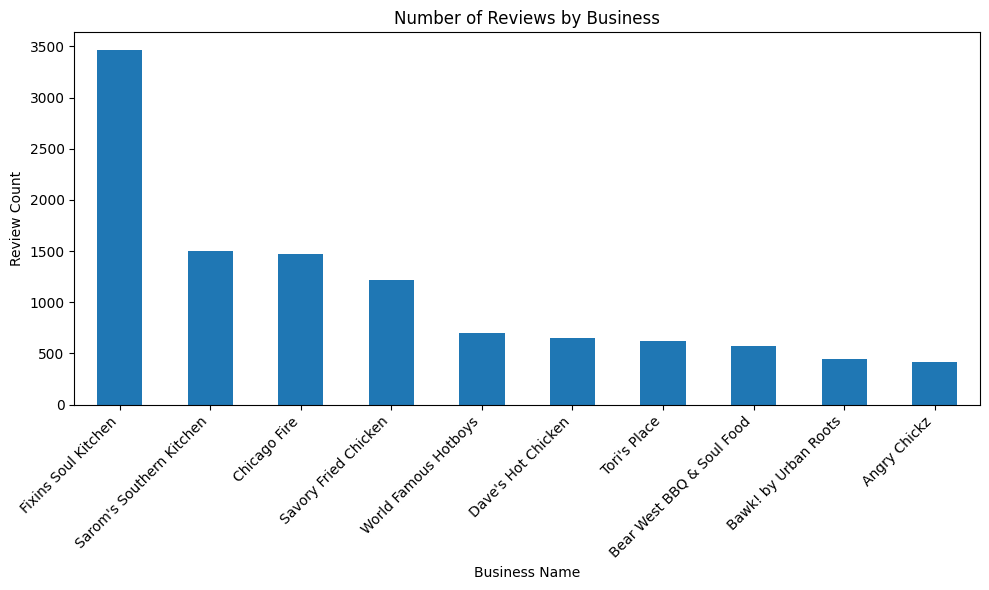

In [14]:
business_counts = df["business_name"].value_counts()
print(business_counts)

plt.figure(figsize=(10, 6))
business_counts.plot(kind="bar")
plt.title("Number of Reviews by Business")
plt.xlabel("Business Name")
plt.ylabel("Review Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## rating Distribution

rating
1     785
2     597
3     937
4    2194
5    6553
Name: count, dtype: int64


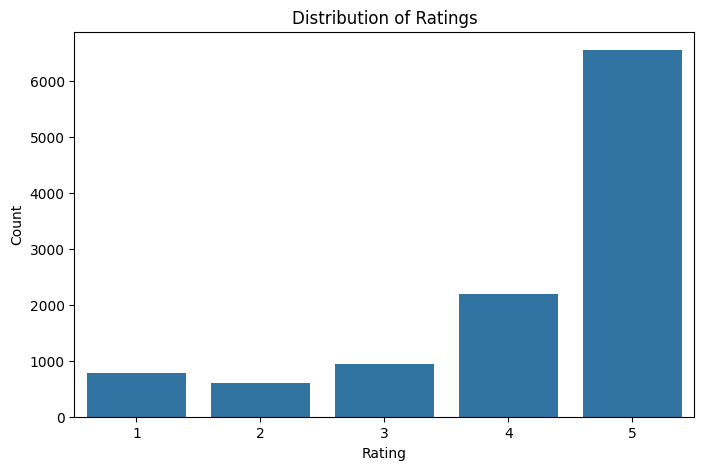

In [15]:
print(df["rating"].value_counts().sort_index())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="rating")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

## Average rating by competitor

business_name
Bear West BBQ & Soul Food    4.581436
Fixins Soul Kitchen          4.337951
Dave's Hot Chicken           4.332820
Tori's Place                 4.285256
Sarom's Southern Kitchen     4.266177
World Famous Hotboys         4.263989
Angry Chickz                 4.014252
Bawk! by Urban Roots         4.000000
Savory Fried Chicken         3.912439
Chicago Fire                 3.788475
Name: rating, dtype: float64


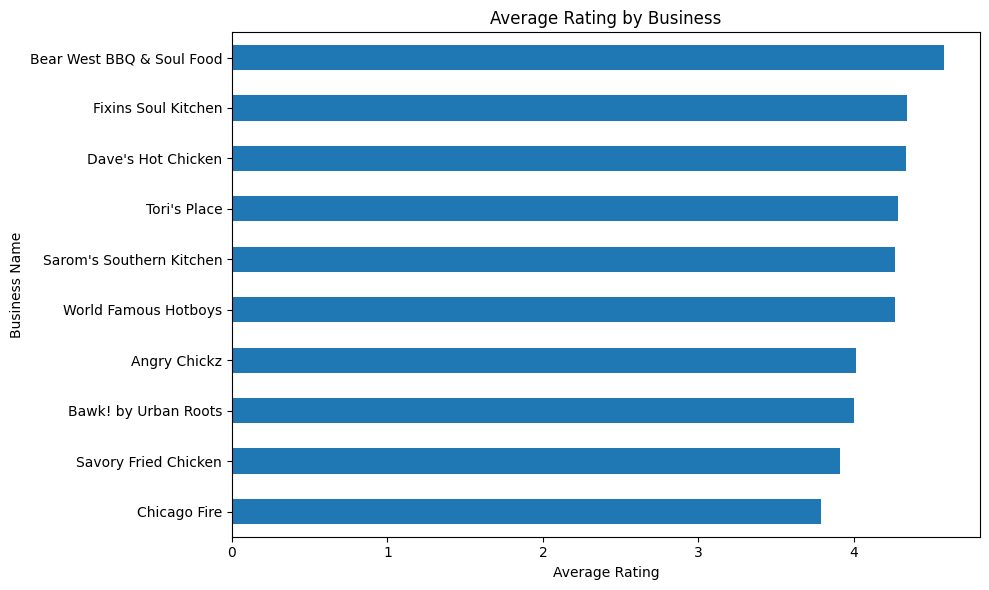

In [16]:
avg_rating_by_business = df.groupby("business_name")["rating"].mean().sort_values(ascending=False)
print(avg_rating_by_business)

plt.figure(figsize=(10, 6))
avg_rating_by_business.sort_values().plot(kind="barh")
plt.title("Average Rating by Business")
plt.xlabel("Average Rating")
plt.ylabel("Business Name")
plt.tight_layout()
plt.show()

## rating Variation by Business

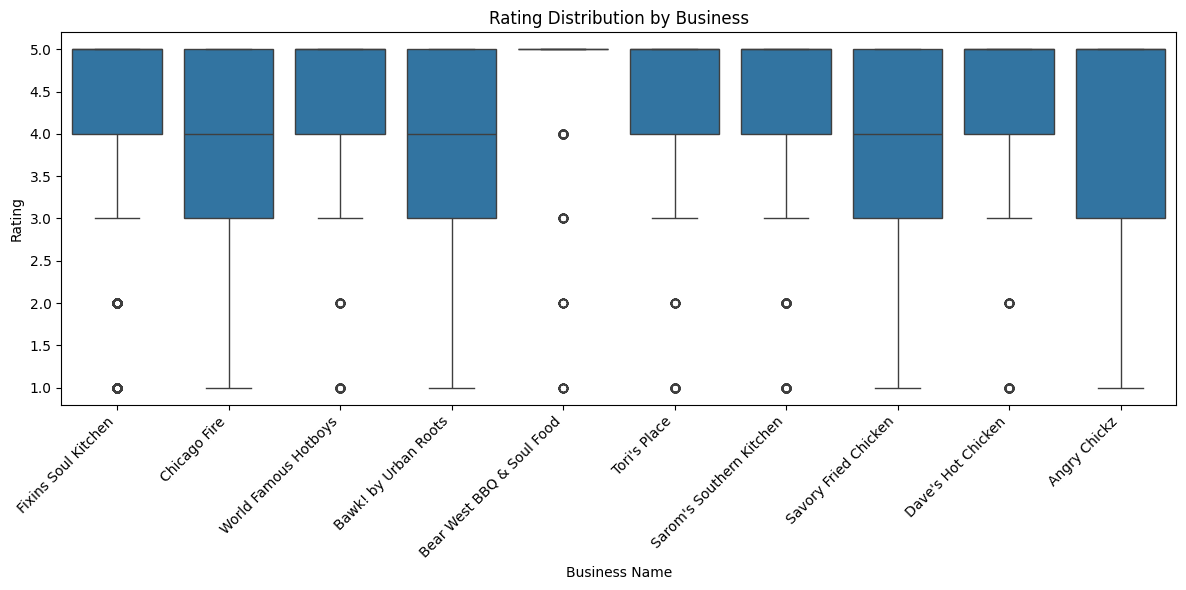

In [17]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="business_name", y="rating")
plt.title("Rating Distribution by Business")
plt.xlabel("Business Name")
plt.ylabel("Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Review Language Distribution

language
en    11066
Name: count, dtype: int64


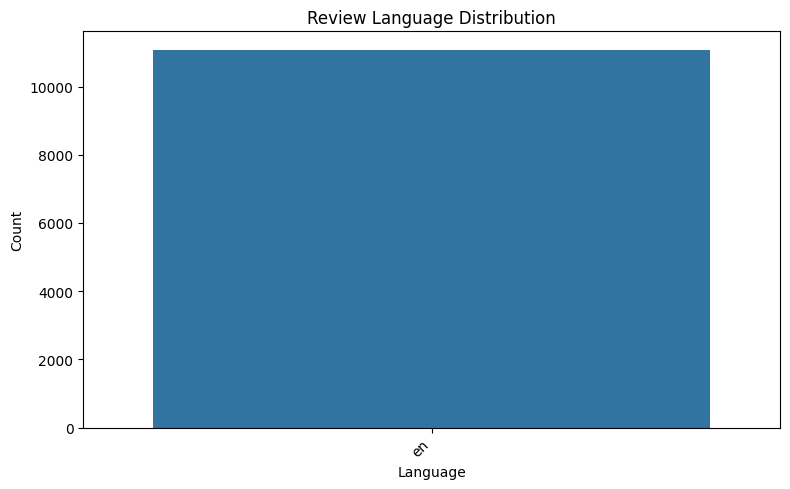

In [18]:
print(df["language"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="language", order=df["language"].value_counts().index)
plt.title("Review Language Distribution")
plt.xlabel("Language")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

author_location
Sacramento, CA         3663
Elk Grove, CA           823
San Francisco, CA       376
CA, CA                  286
Roseville, CA           197
West Sacramento, CA     193
Stockton, CA            178
San Jose, CA            176
Oakland, CA             143
Carmichael, CA          141
Name: count, dtype: int64


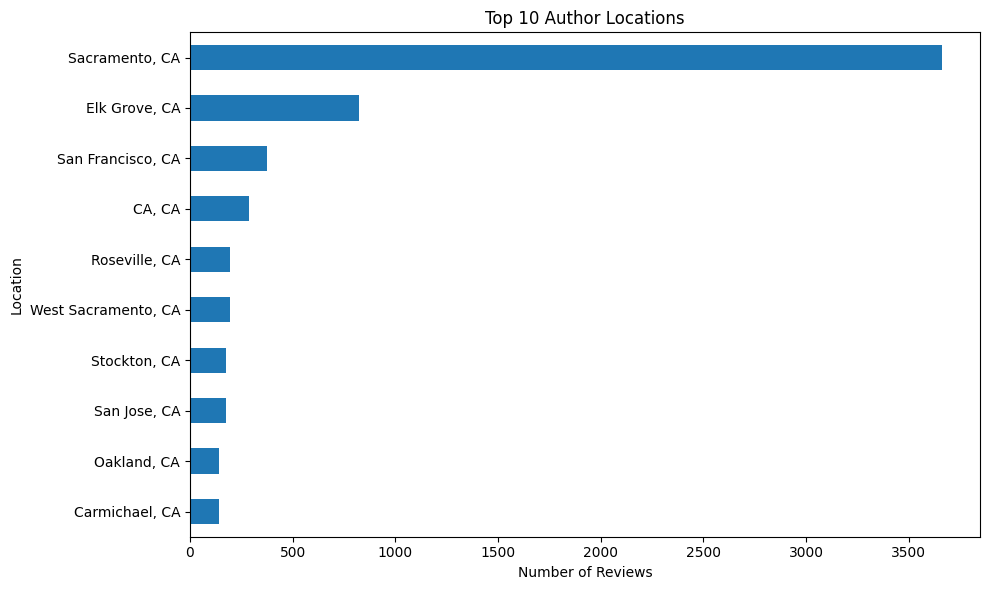

In [19]:
# Author Location Distribution

top_locations = df["author_location"].value_counts().head(10)
print(top_locations)

plt.figure(figsize=(10, 6))
top_locations.sort_values().plot(kind="barh")
plt.title("Top 10 Author Locations")
plt.xlabel("Number of Reviews")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

In [20]:
# Engagement metrices

engagement_cols = ["reactions/helpful", "reactions/love_this", "reactions/oh_no", "reactions/thanks"]

print(df[engagement_cols].describe())

       reactions/helpful  reactions/love_this  reactions/oh_no  \
count       11066.000000         11066.000000     11066.000000   
mean            0.956262             0.749864         0.043286   
std             3.090630             2.838086         0.298250   
min             0.000000             0.000000         0.000000   
25%             0.000000             0.000000         0.000000   
50%             0.000000             0.000000         0.000000   
75%             1.000000             1.000000         0.000000   
max            90.000000            81.000000        18.000000   

       reactions/thanks  
count      11066.000000  
mean           0.126423  
std            0.489024  
min            0.000000  
25%            0.000000  
50%            0.000000  
75%            0.000000  
max           16.000000  


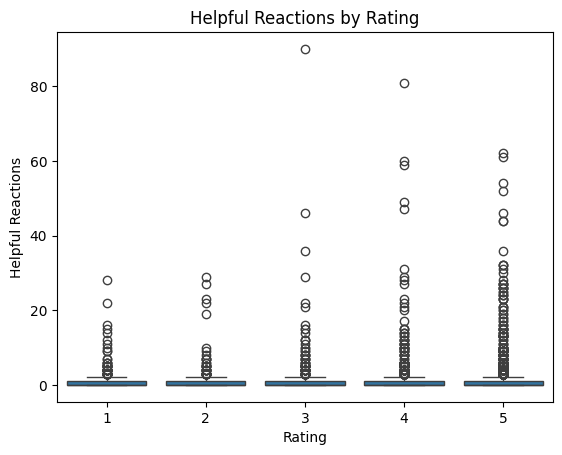

In [21]:
# Plot - Engagement Vs. rating

sns.boxplot(data=df, x="rating", y="reactions/helpful")
plt.title("Helpful Reactions by Rating")
plt.xlabel("Rating")
plt.ylabel("Helpful Reactions")
plt.show()

count    11066.000000
mean       488.313573
std        462.938674
min         19.000000
25%        185.000000
50%        331.000000
75%        624.000000
max       4962.000000
Name: review_length, dtype: float64


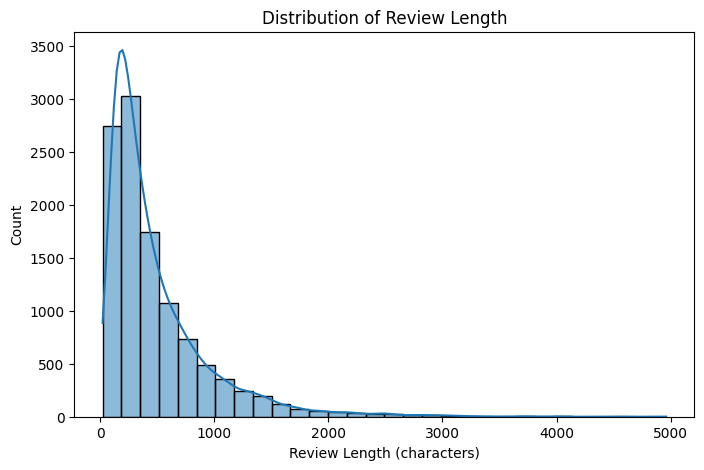

In [22]:
# Creatiing new feature called review length to understand the distribution

df["review_length"] = df["text"].astype(str).apply(len)

print(df["review_length"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["review_length"], bins=30, kde=True)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length (characters)")
plt.ylabel("Count")
plt.show()

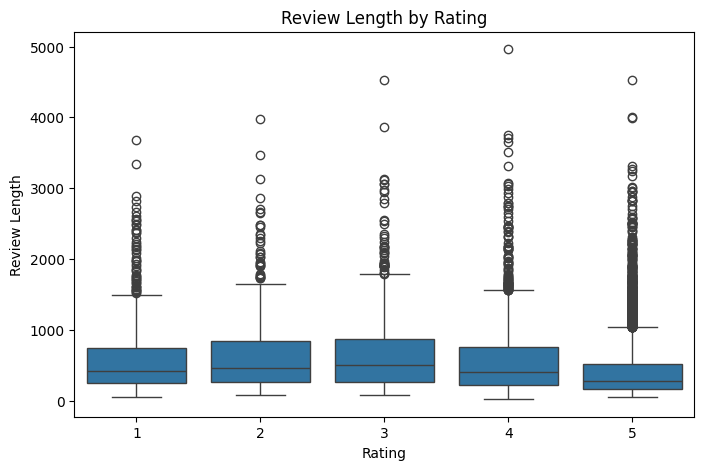

In [23]:
# Plot - Review length Vs. rating

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="rating", y="review_length")
plt.title("Review Length by Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length")
plt.show()

In [24]:
# Converting Created_Date to dateTime

df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")

# Check the result
print(df["created_date"].dtype)
print(df["created_date"].head())
print("Missing dates after conversion:", df["created_date"].isnull().sum())

datetime64[ns, UTC-07:00]
777     2021-04-23 06:15:17-07:00
14503                         NaT
11757                         NaT
5124                          NaT
4736    2021-10-08 02:34:06-07:00
Name: created_date, dtype: datetime64[ns, UTC-07:00]
Missing dates after conversion: 3717


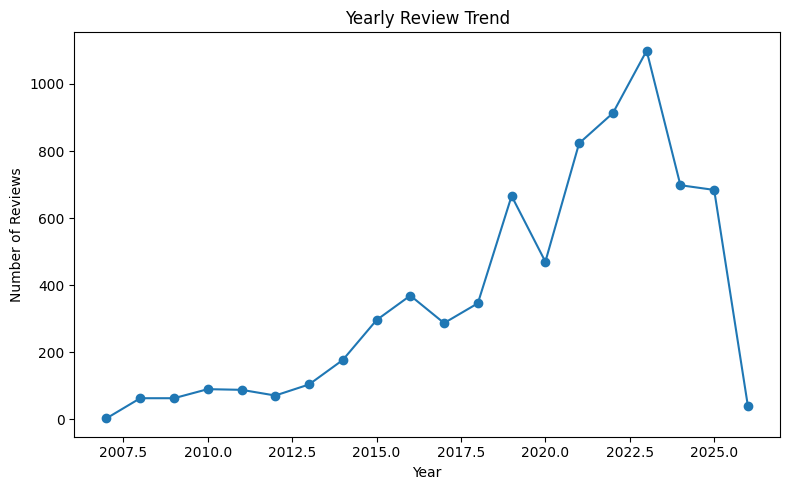

In [25]:
df["year"] = df["created_date"].dt.year

yearly_reviews = df.groupby("year").size()

plt.figure(figsize=(8, 5))
plt.plot(yearly_reviews.index, yearly_reviews.values, marker="o")

plt.title("Yearly Review Trend")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

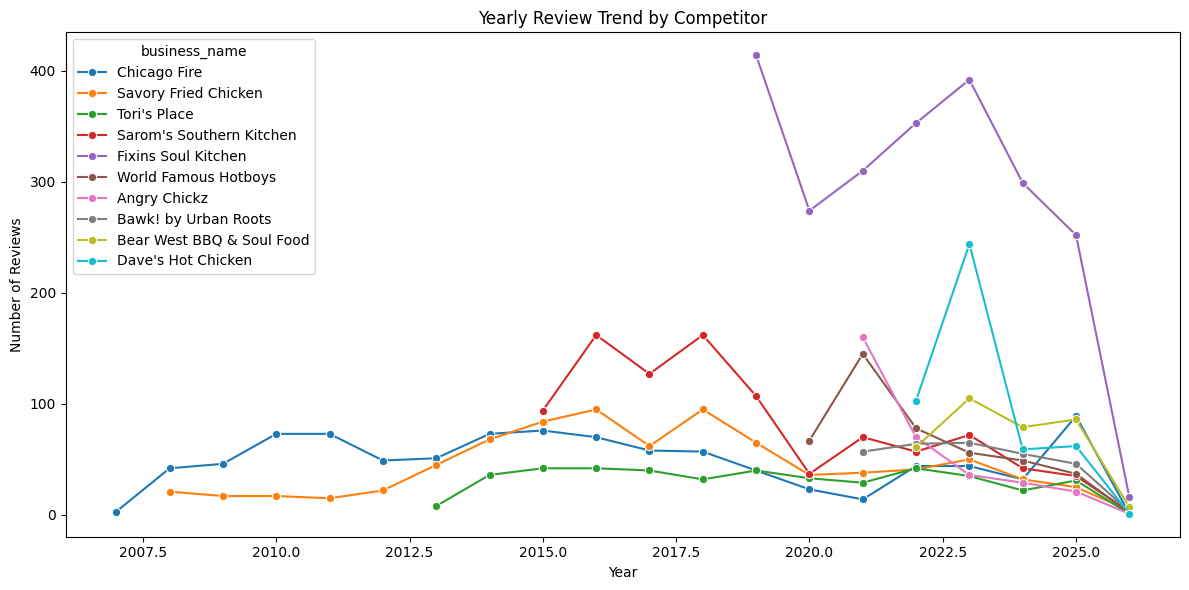

In [26]:
# Create year column
df["year"] = df["created_date"].dt.year

# Count reviews by year and business
yearly_business = df.groupby(["year", "business_name"]).size().reset_index(name="reviews")

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_business, x="year", y="reviews", hue="business_name", marker="o")

plt.title("Yearly Review Trend by Competitor")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

#### The yearly review trend analysis reveals clear differences in competitor performance within the Sacramento restaurant market. Fixins Soul Kitchen stands out as the dominant competitor, consistently generating the highest number of reviews, indicating strong customer engagement and brand visibility. However, its slight decline in recent years may suggest an opportunity for new entrants like The Roost. Dave’s Hot Chicken shows a rapid rise in review volume starting around 2021, highlighting it as a fast-growing and potentially disruptive competitor driven by strong marketing or customer appeal. Mid-tier competitors such as Chicago Fire, Savory Fried Chicken, and Tori’s Place exhibit relatively stable performance over time, suggesting a steady but less aggressive market presence. In contrast, Sarom’s Southern Kitchen shows a noticeable decline after its peak years, indicating potential weaknesses in maintaining customer satisfaction or competitiveness. Additionally, several newer competitors have emerged in recent years, contributing to an increasingly competitive landscape. Overall, the market demonstrates strong growth followed by stabilization, with the apparent drop in the most recent years likely due to incomplete data rather than an actual decline in demand. These insights suggest that The Roost can strategically position itself by targeting gaps left by declining competitors while differentiating itself from both dominant and rapidly growing brands.


year_month
2007-10    4.000000
2007-11    2.000000
2008-03    4.400000
2008-04    3.600000
2008-05    3.428571
             ...   
2025-09    4.160920
2025-10    4.285714
2025-11    4.000000
2026-03    4.358974
NaT        4.195050
Name: rating, Length: 162, dtype: float64


/var/folders/l2/kkrqvk_j4dzdrf_zmgxd63280000gn/T/ipykernel_64520/1352896398.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["year_month"] = df["created_date"].dt.to_period("M").astype(str)


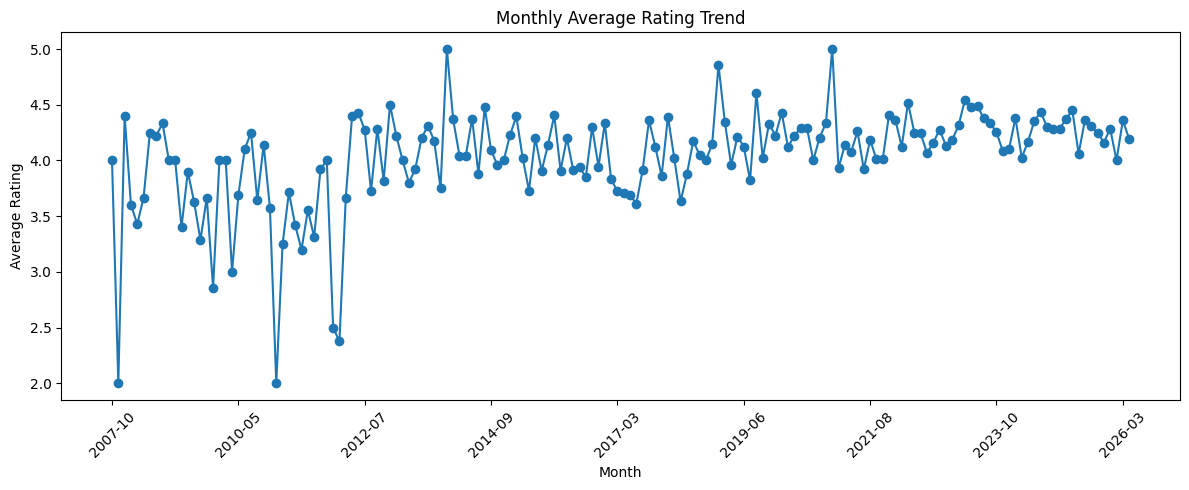

In [27]:
# Monthly Averagre rating trend
df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
df["year_month"] = df["created_date"].dt.to_period("M").astype(str)
monthly_avg_rating = df.groupby("year_month")["rating"].mean()
print(monthly_avg_rating)

plt.figure(figsize=(12, 5))
monthly_avg_rating.plot(kind="line", marker="o")
plt.title("Monthly Average Rating Trend")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

business_name  Angry Chickz  Bawk! by Urban Roots  Bear West BBQ & Soul Food  \
year_month                                                                     
2007-10                 NaN                   NaN                        NaN   
2007-11                 NaN                   NaN                        NaN   
2008-03                 NaN                   NaN                        NaN   
2008-04                 NaN                   NaN                        NaN   
2008-05                 NaN                   NaN                        NaN   

business_name  Chicago Fire  Dave's Hot Chicken  Fixins Soul Kitchen  \
year_month                                                             
2007-10            4.000000                 NaN                  NaN   
2007-11            2.000000                 NaN                  NaN   
2008-03            4.250000                 NaN                  NaN   
2008-04            3.444444                 NaN                  NaN   
2008-05

<Figure size 1200x600 with 0 Axes>

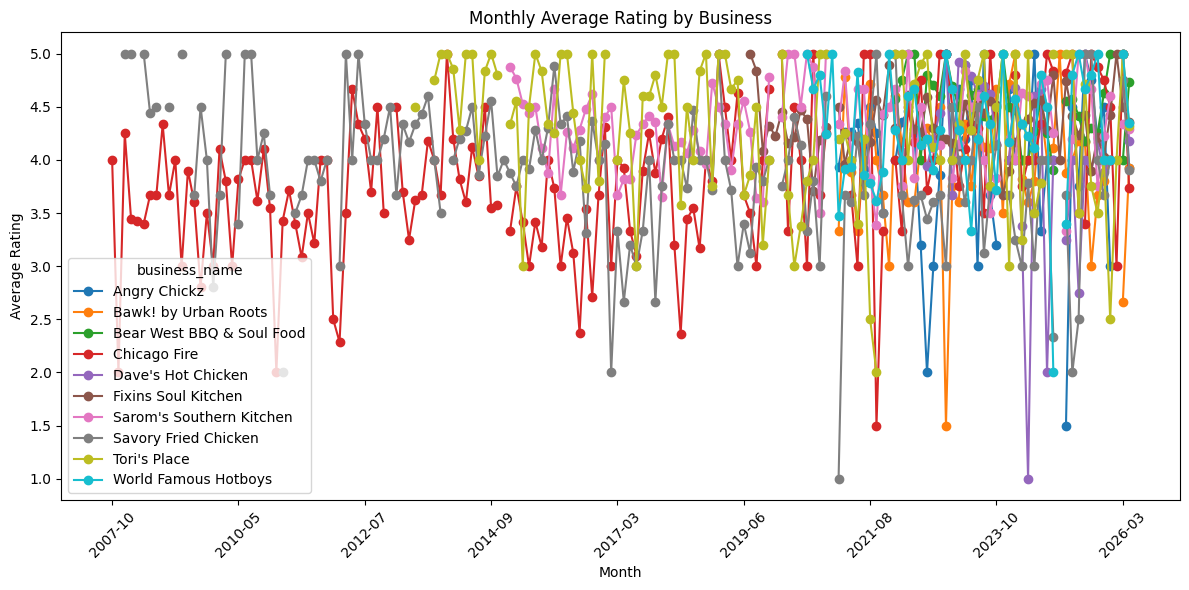

In [28]:
#Monthly average rating trend per competitor
monthly_business_rating = df.groupby(["year_month", "business_name"])["rating"].mean().unstack()

print(monthly_business_rating.head())

plt.figure(figsize=(12, 6))
monthly_business_rating.plot(marker="o", figsize=(12, 6))
plt.title("Monthly Average Rating by Business")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sentiment_category
Positive    8747
Negative    1382
Neutral      937
Name: count, dtype: int64


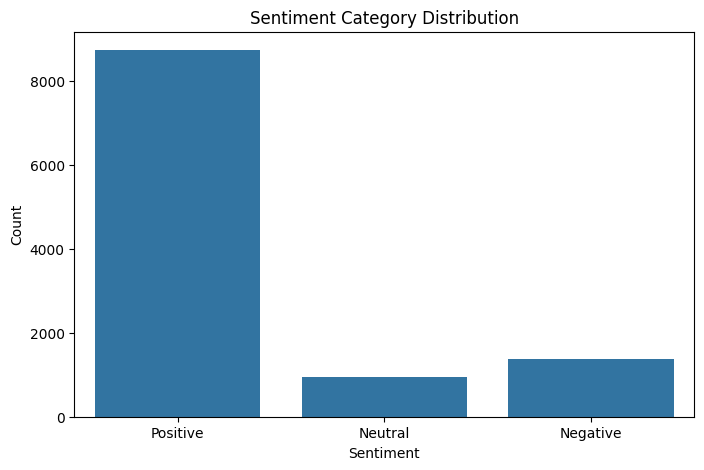

In [29]:
# EDA - Sentiment check

def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

df["sentiment_category"] = df["rating"].apply(sentiment_label)

print(df["sentiment_category"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="sentiment_category", order=["Positive", "Neutral", "Negative"])
plt.title("Sentiment Category Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

sentiment_category          Negative    Neutral   Positive
business_name                                             
Angry Chickz               16.152019   9.738717  74.109264
Bawk! by Urban Roots       14.672686  11.060948  74.266366
Bear West BBQ & Soul Food   6.129597   4.903678  88.966725
Chicago Fire               17.966102  13.559322  68.474576
Dave's Hot Chicken         12.326656   4.622496  83.050847
Fixins Soul Kitchen        10.101010   6.724387  83.174603
Sarom's Southern Kitchen   11.074049   7.471648  81.454303
Savory Fried Chicken       16.121113  12.602291  71.276596
Tori's Place               11.858974   7.211538  80.929487
World Famous Hotboys       11.764706   6.456241  81.779053


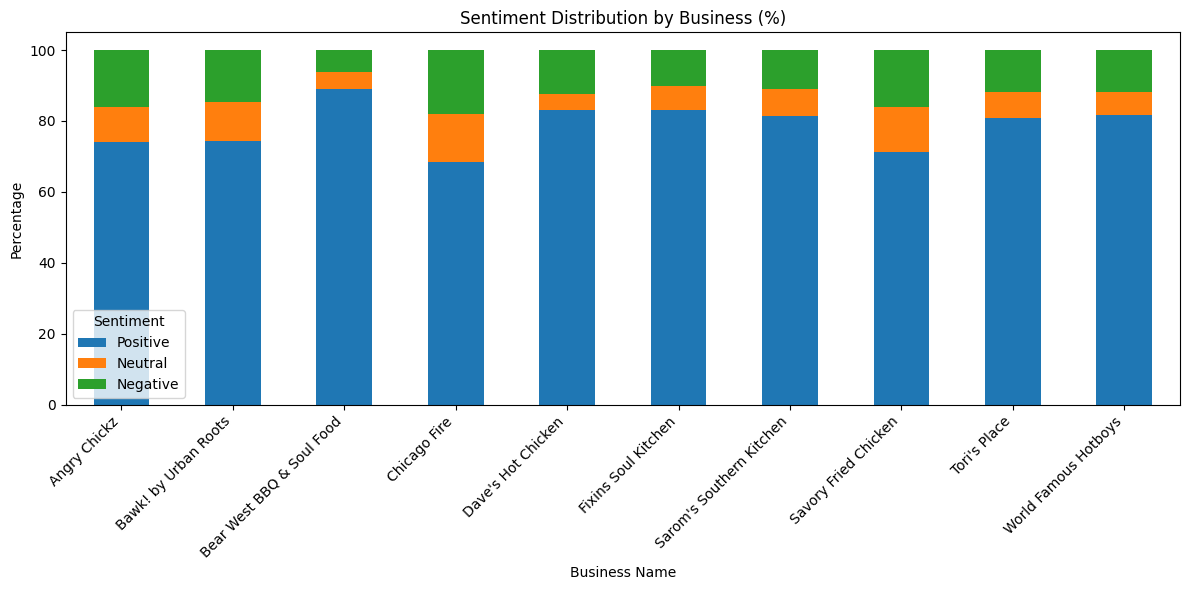

In [30]:
# Sentiment by Competitor

sentiment_by_business = pd.crosstab(df["business_name"], df["sentiment_category"], normalize="index") * 100
print(sentiment_by_business)

sentiment_by_business[["Positive", "Neutral", "Negative"]].plot(kind="bar", stacked=True, figsize=(12, 6))
plt.title("Sentiment Distribution by Business (%)")
plt.xlabel("Business Name")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()

In [31]:
# Strongest and Weakest competitor

competitor_summary = df.groupby("business_name").agg(
    total_reviews=("review_id", "count"),
    avg_rating=("rating", "mean"),
    avg_review_length=("review_length", "mean"),
    avg_helpful=("reactions/helpful", "mean")
).sort_values(by="avg_rating", ascending=False)

print(competitor_summary)

                           total_reviews  avg_rating  avg_review_length  \
business_name                                                             
Bear West BBQ & Soul Food            571    4.581436         417.737303   
Fixins Soul Kitchen                 3465    4.337951         505.842713   
Dave's Hot Chicken                   649    4.332820         323.251156   
Tori's Place                         624    4.285256         493.392628   
Sarom's Southern Kitchen            1499    4.266177         449.098065   
World Famous Hotboys                 696    4.263989         472.434720   
Angry Chickz                         421    4.014252         442.049881   
Bawk! by Urban Roots                 443    4.000000         495.216704   
Savory Fried Chicken                1222    3.912439         510.393617   
Chicago Fire                        1475    3.788475         585.130847   

                           avg_helpful  
business_name                           
Bear West BBQ & S

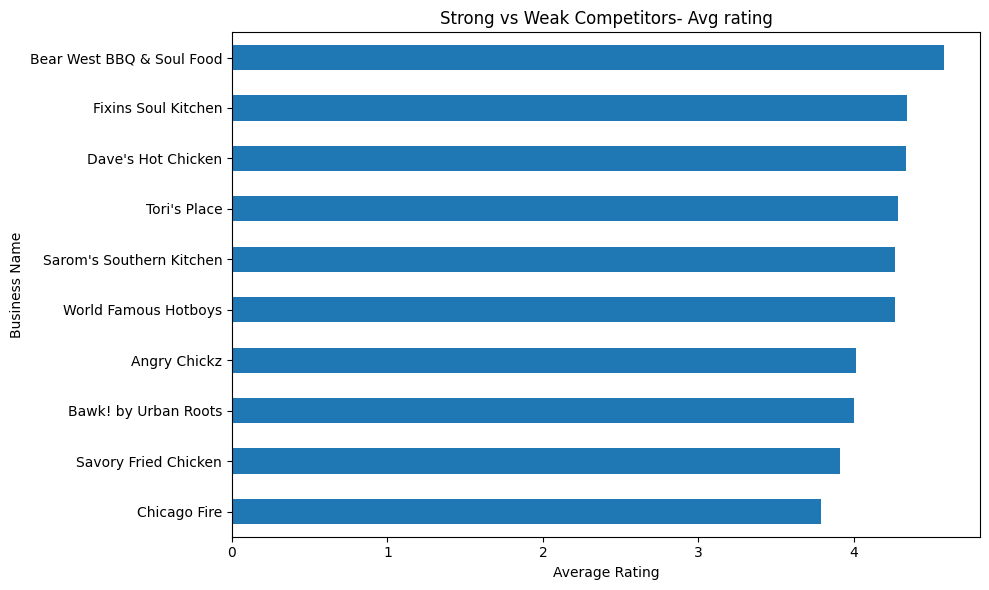

In [32]:
# Plot - Stronges vs weakest

competitor_summary = df.groupby("business_name").agg(
    total_reviews=("review_id", "count"),
    avg_rating=("rating", "mean")
).sort_values(by="avg_rating", ascending=False)

# Plot
plt.figure(figsize=(10, 6))
competitor_summary["avg_rating"].sort_values().plot(kind="barh")

plt.title("Strong vs Weak Competitors- Avg rating")
plt.xlabel("Average Rating")
plt.ylabel("Business Name")

plt.tight_layout()
plt.show()

In [33]:
#Summary
print("Final dataset shape:", df.shape)
print("\nBusinesses in dataset:", df["business_name"].nunique())
print("Date range:", df["created_date"].min(), "to", df["created_date"].max())
print("\nSentiment distribution:")
print(df["sentiment_category"].value_counts(normalize=True) * 100)
print("\nTop competitors by average rating:")
print(competitor_summary.head())
print("\nBottom competitors by average rating:")
print(competitor_summary.tail())

Final dataset shape: (11066, 17)

Businesses in dataset: 10
Date range: 2007-10-20 17:36:52-07:00 to 2026-03-26 15:16:31-07:00

Sentiment distribution:
sentiment_category
Positive    79.043918
Negative    12.488704
Neutral      8.467378
Name: proportion, dtype: float64

Top competitors by average rating:
                           total_reviews  avg_rating
business_name                                       
Bear West BBQ & Soul Food            571    4.581436
Fixins Soul Kitchen                 3465    4.337951
Dave's Hot Chicken                   649    4.332820
Tori's Place                         624    4.285256
Sarom's Southern Kitchen            1499    4.266177

Bottom competitors by average rating:
                      total_reviews  avg_rating
business_name                                  
World Famous Hotboys            696    4.263989
Angry Chickz                    421    4.014252
Bawk! by Urban Roots            443    4.000000
Savory Fried Chicken           1222    3.912

# Needs improvement - Trigrams - Not working as expected, gets food name!!!

In [34]:
# Trigrams for restaurants, both positive and negative

import re
from sklearn.feature_extraction.text import CountVectorizer

# Clean text function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Sentiment labeling
def sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating == 3:
        return "Neutral"
    else:
        return "Negative"

# Apply cleaning and sentiment
df["clean_text"] = df["text"].astype(str).apply(clean_text)
df["sentiment_category"] = df["rating"].apply(sentiment_label)

# Function to get top trigrams
def get_top_trigrams(text_series, n=10):
    text_data = text_series.dropna().tolist()
    
    if len(text_data) == 0:
        return []
    
    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(3, 3),
        max_features=1000
    )
    
    X = vectorizer.fit_transform(text_data)
    sums = X.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    
    trigram_counts = list(zip(terms, sums))
    trigram_counts = sorted(trigram_counts, key=lambda x: x[1], reverse=True)
    
    return trigram_counts[:n]

# Loop Run for all restaurants
restaurants = df["business_name"].dropna().unique()

for restaurant in restaurants:
    print(f"Restaurant: {restaurant}")
    
    # Positive reviews
    pos_text = df[(df["business_name"] == restaurant) & 
                  (df["sentiment_category"] == "Positive")]["clean_text"]
    
    # Negative reviews
    neg_text = df[(df["business_name"] == restaurant) & 
                  (df["sentiment_category"] == "Negative")]["clean_text"]
    
    top_pos_trigrams = get_top_trigrams(pos_text)
    top_neg_trigrams = get_top_trigrams(neg_text)
    
    print("\nTop Positive Trigrams:")
    for trigram, count in top_pos_trigrams:
        print(f"{trigram} ({count})")
    
    print("\nTop Negative Trigrams:")
    for trigram, count in top_neg_trigrams:
        print(f"{trigram} ({count})")

Restaurant: Fixins Soul Kitchen

Top Positive Trigrams:
red beans rice (188)
fried green tomatoes (168)
fried deviled eggs (146)
best soul food (94)
fixins soul kitchen (90)
greens mac cheese (82)
chicken mac cheese (81)
black eyed peas (65)
best fried chicken (63)
ordered fried chicken (63)

Top Negative Trigrams:
smothered pork chops (19)
red beans rice (17)
black eyed peas (16)
fried green tomatoes (10)
greens mac cheese (8)
fried deviled eggs (7)
hot chicken sandwich (7)
ordered smothered pork (7)
fixins soul kitchen (6)
heard good things (6)
Restaurant: Chicago Fire

Top Positive Trigrams:
deep dish pizza (192)
deep dish pizzas (40)
chicago style pizza (36)
deep dish crust (27)
chicago deep dish (25)
deep dish stuffed (25)
ordered deep dish (23)
crust deep dish (20)
best deep dish (19)
love deep dish (17)

Top Negative Trigrams:
deep dish pizza (30)
ordered deep dish (13)
chicago style pizza (11)
deep dish pizzas (6)
chicago deep dish (5)
better deep dish (4)
crust deep dish (4)
d

Restaurant: Fixins Soul Kitchen


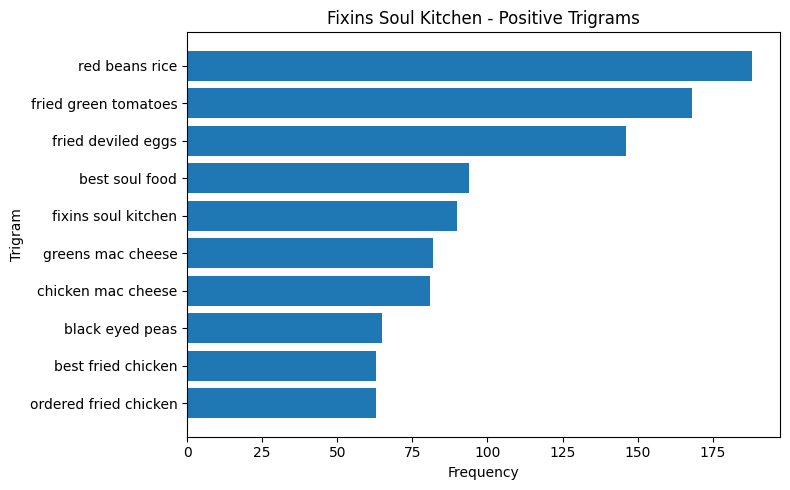

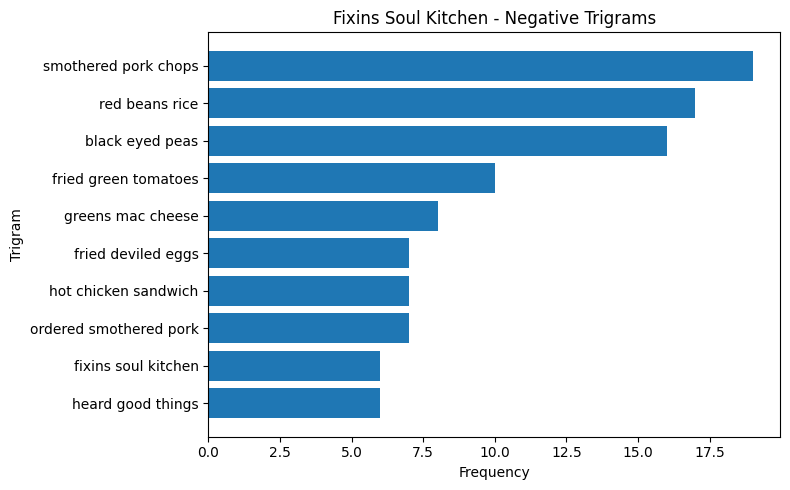

Restaurant: Chicago Fire


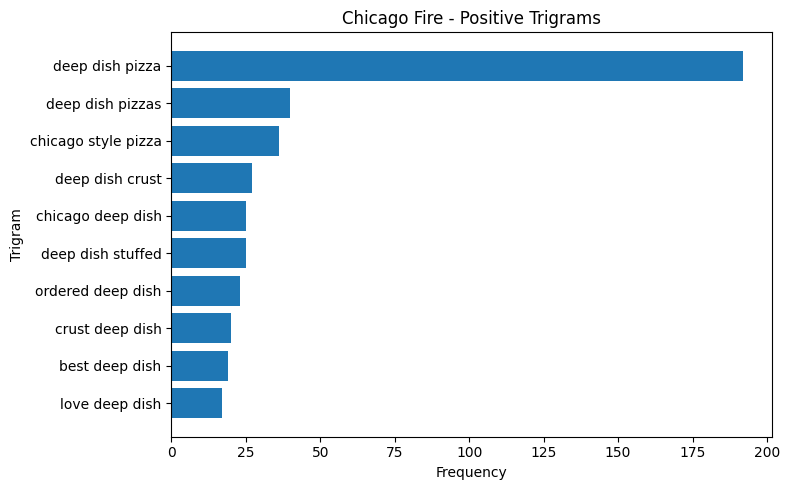

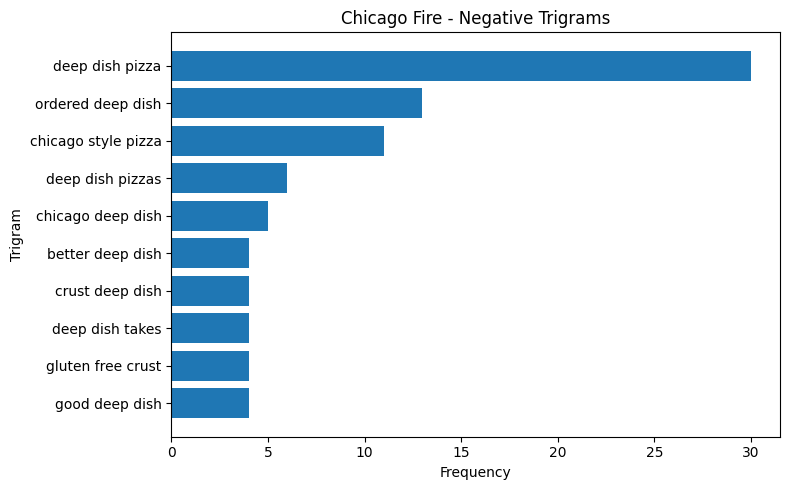

Restaurant: World Famous Hotboys


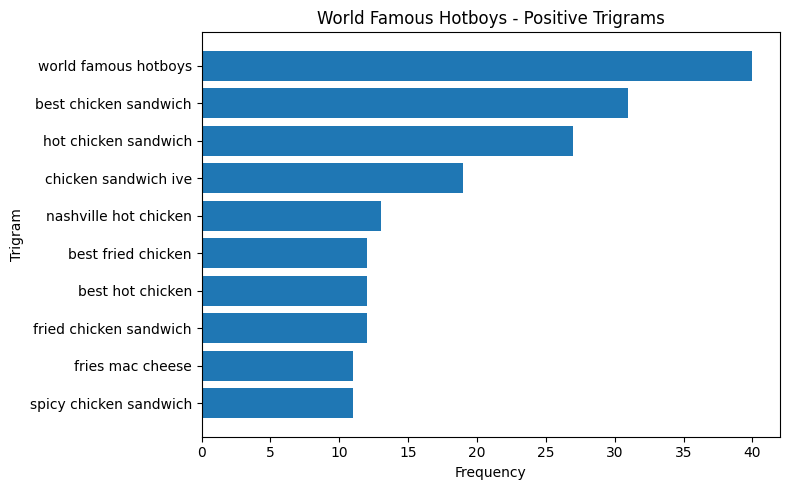

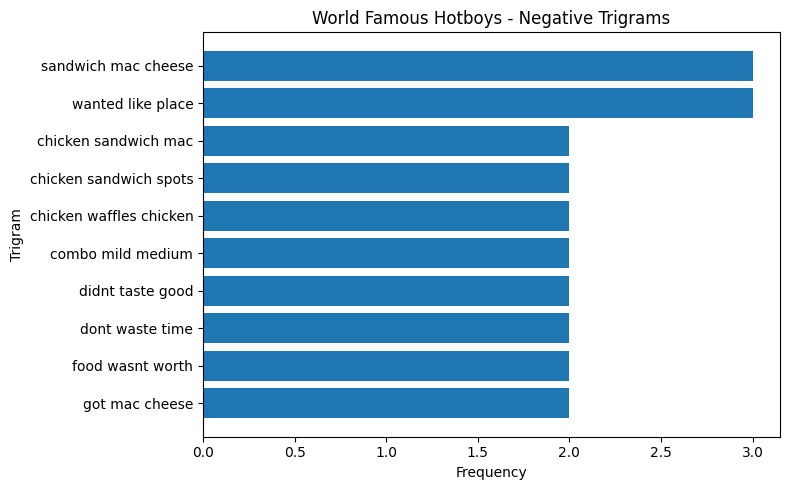

Restaurant: Bawk! by Urban Roots


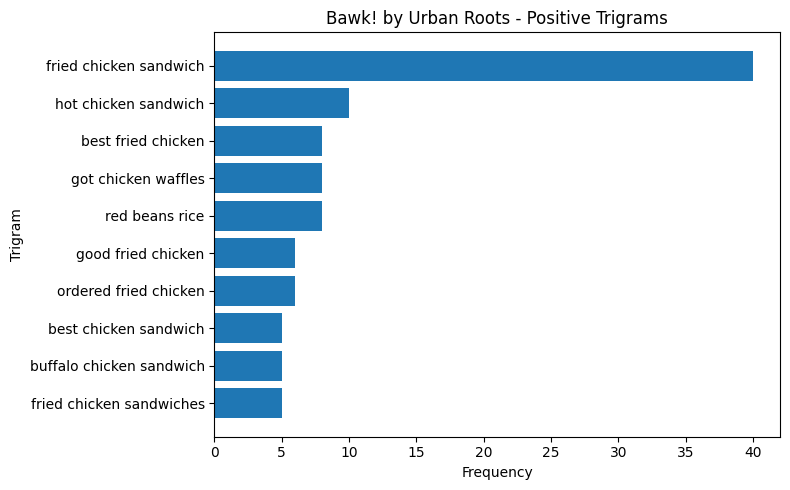

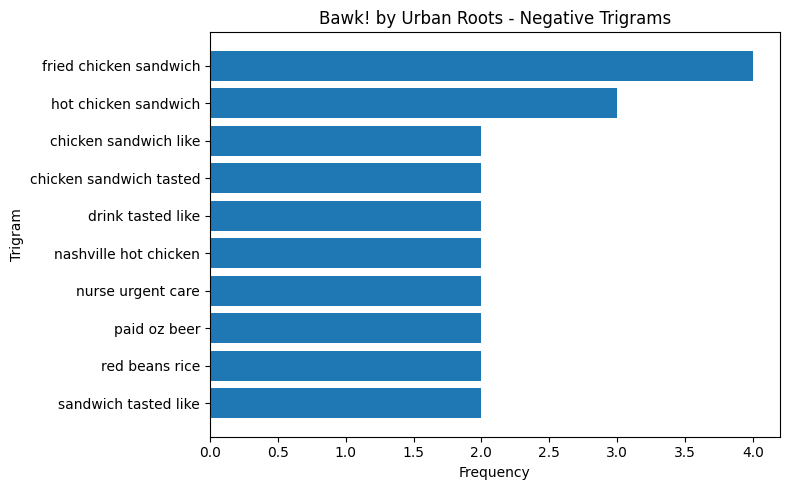

Restaurant: Bear West BBQ & Soul Food


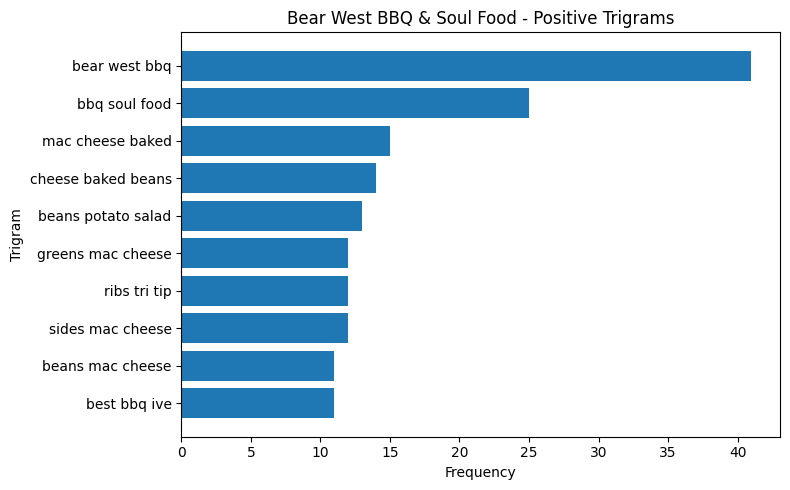

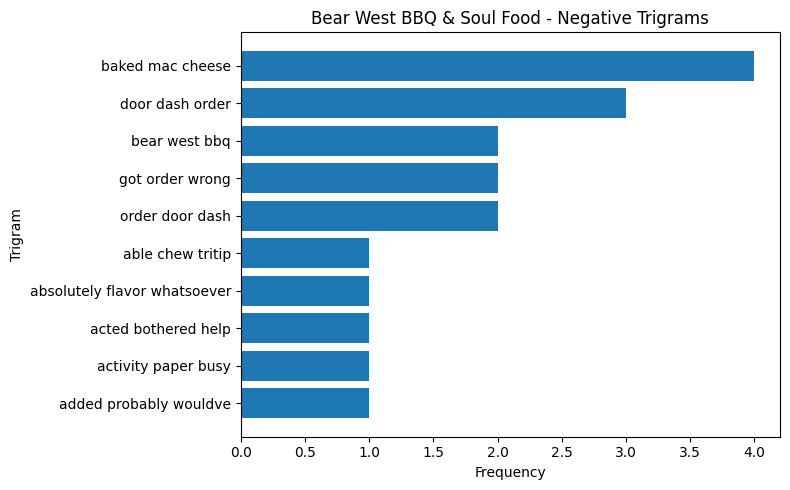

Restaurant: Tori's Place


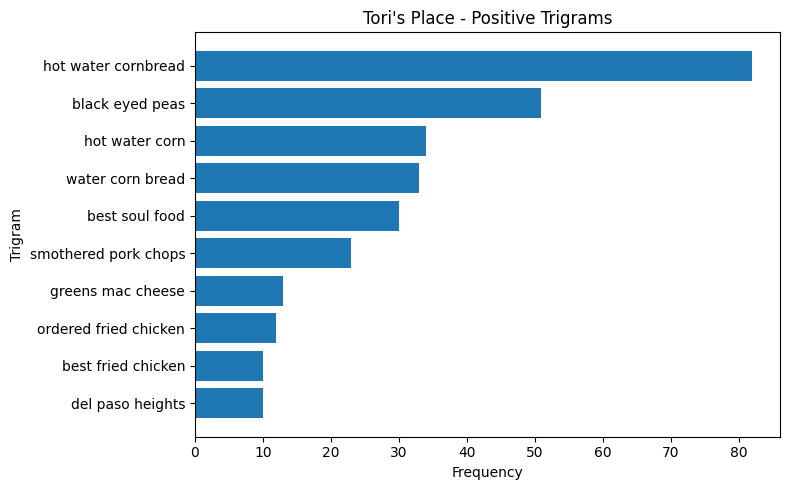

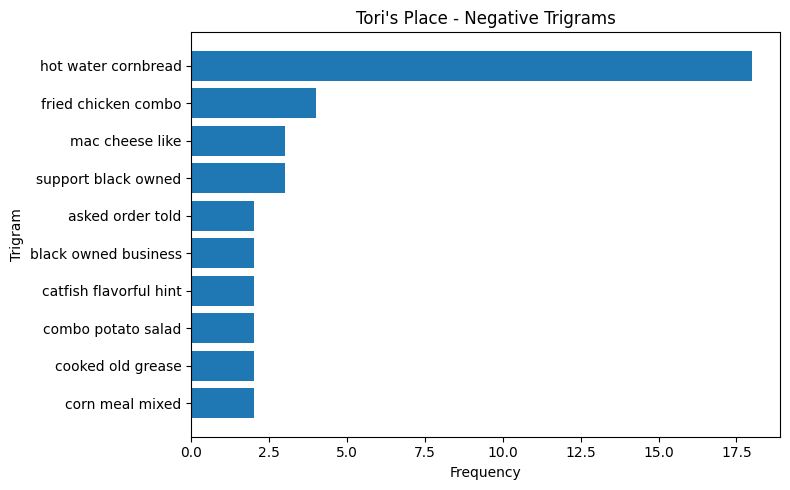

Restaurant: Sarom's Southern Kitchen


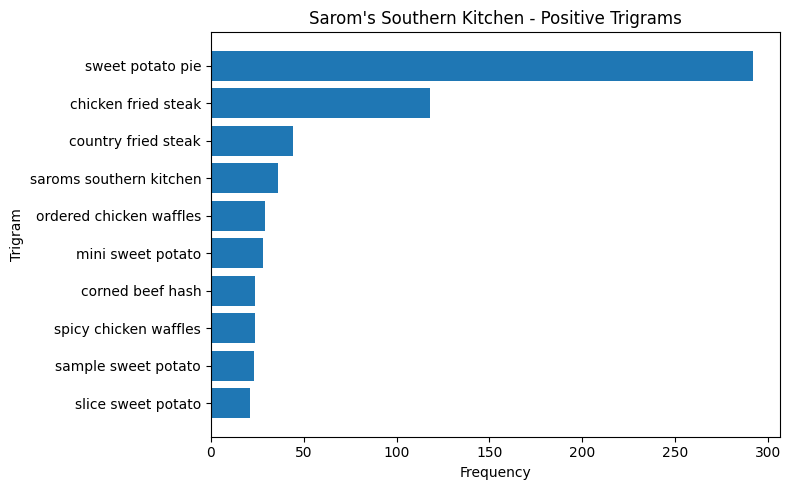

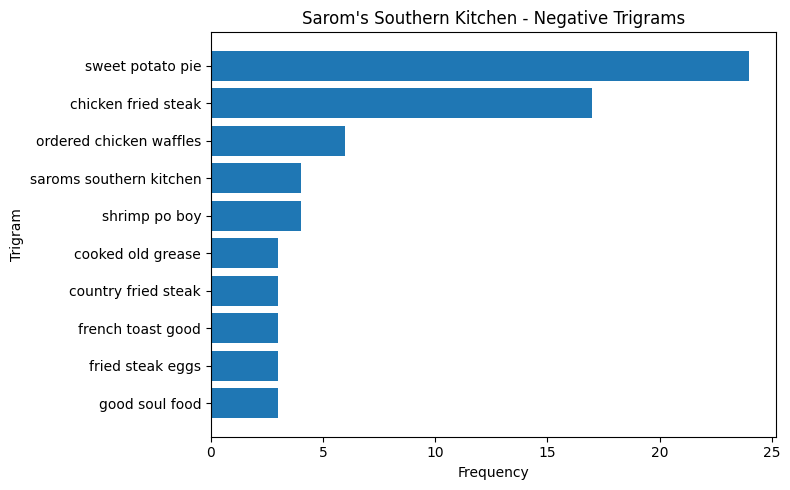

Restaurant: Savory Fried Chicken


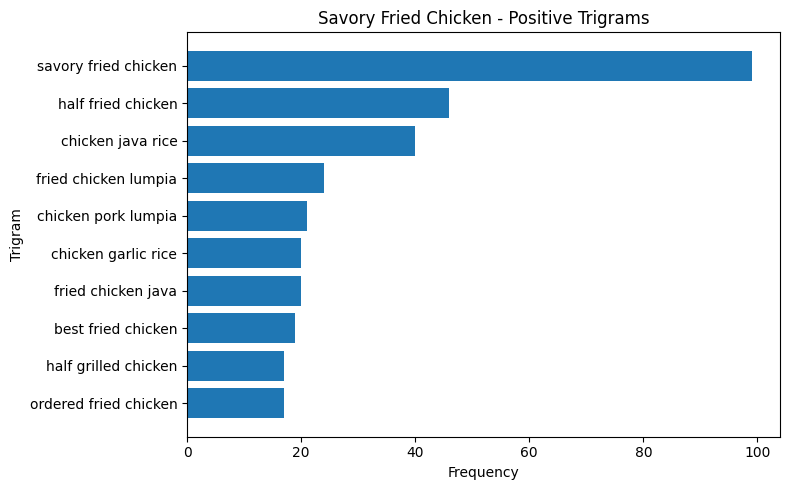

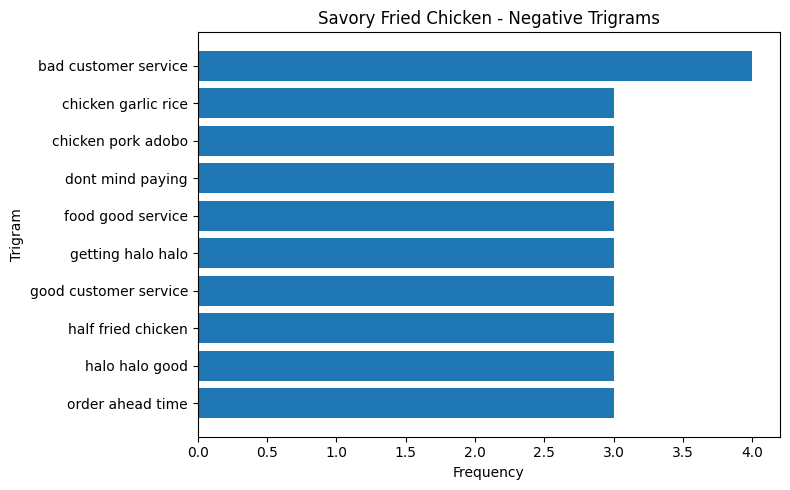

Restaurant: Dave's Hot Chicken


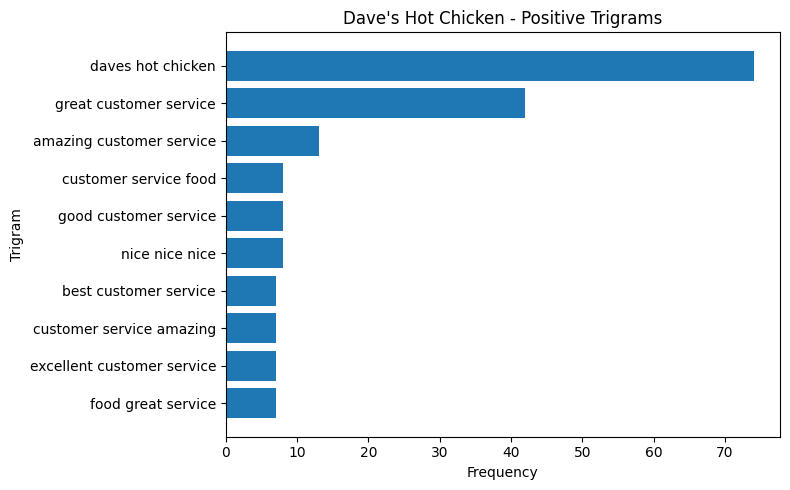

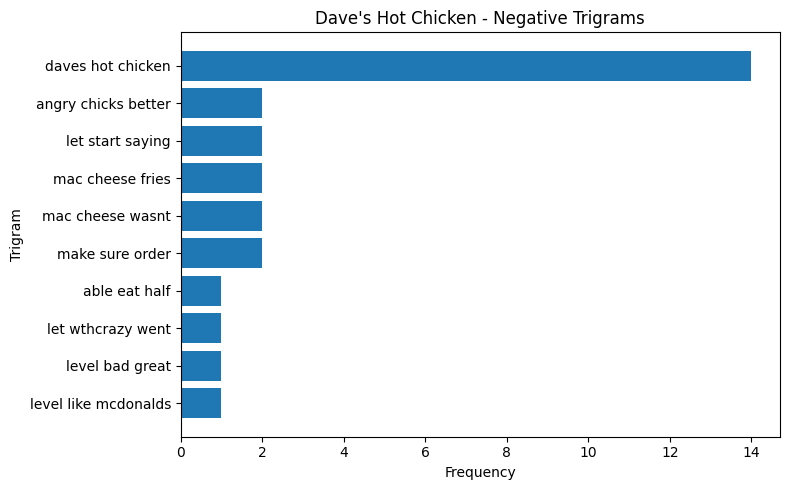

Restaurant: Angry Chickz


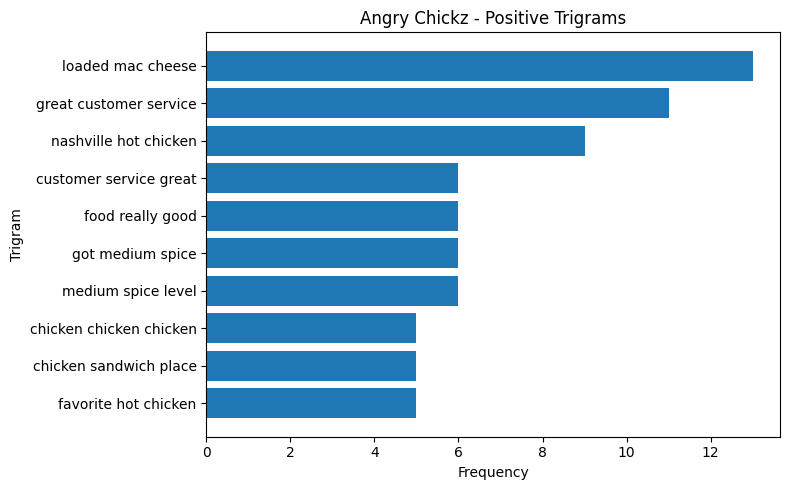

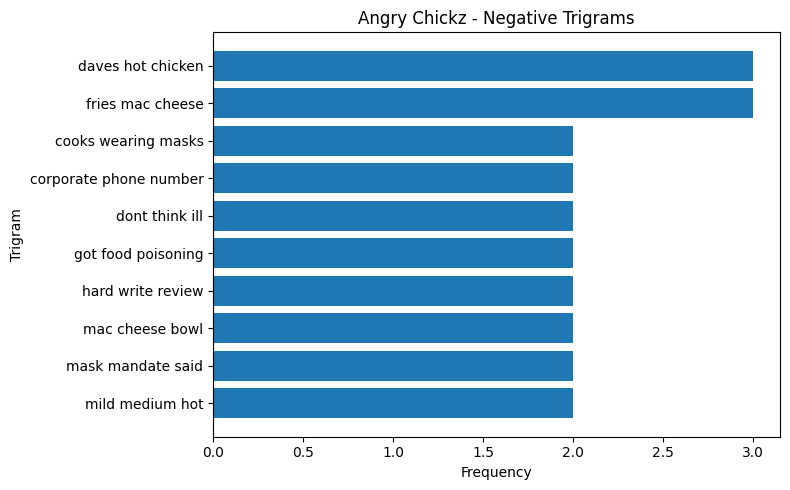

In [35]:
#TRigrams barchart

import matplotlib.pyplot as plt

def plot_trigrams(trigrams, title):
    if len(trigrams) == 0:
        print(f"No data for {title}")
        return
    
    phrases = [t[0] for t in trigrams]
    counts = [t[1] for t in trigrams]
    
    plt.figure(figsize=(8, 5))
    plt.barh(phrases[::-1], counts[::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Trigram")
    plt.tight_layout()
    plt.show()

# Loop through restaurants
for restaurant in restaurants:
    print(f"Restaurant: {restaurant}")
    
    pos_text = df[(df["business_name"] == restaurant) & 
                  (df["sentiment_category"] == "Positive")]["clean_text"]
    
    neg_text = df[(df["business_name"] == restaurant) & 
                  (df["sentiment_category"] == "Negative")]["clean_text"]
    
    top_pos_trigrams = get_top_trigrams(pos_text)
    top_neg_trigrams = get_top_trigrams(neg_text)
    
    plot_trigrams(top_pos_trigrams, f"{restaurant} - Positive Trigrams")
    plot_trigrams(top_neg_trigrams, f"{restaurant} - Negative Trigrams")

In [36]:
#Comparison

summary_table = df.groupby("business_name").agg(
    total_reviews=("review_id", "count"),
    avg_rating=("rating", "mean"),
    positive_reviews=("sentiment_category", lambda x: (x == "Positive").sum()),
    negative_reviews=("sentiment_category", lambda x: (x == "Negative").sum())
).reset_index()

# Merge trigram insights
final_table = summary_table.merge(insights_df, on="business_name")

# Sort by rating
final_table = final_table.sort_values(by="avg_rating", ascending=False)

print(final_table)

NameError: name 'insights_df' is not defined

In [37]:
df.to_csv("nlpdata.csv", index=False)

In [38]:
df.head()

,author_location,author_name,business_id,business_name,created_date,language,rating,reactions/helpful,reactions/love_this,reactions/oh_no,reactions/thanks,review_id,text,review_length,year,year_month,sentiment_category,clean_text
777,"San Francisco Bay Area, CA",Lori N.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,2021-04-23 06:15:17-07:00,en,3,90,81,0,0,bOp4FgfT_cte3Yt5ZiEBTQ,"With the high ratings, I came with high hopes,...",1426,2021.0,2021-04,Neutral,with the high ratings i came with high hopes y...
14503,"Sacramento, CA",May A.,myoaFyZ9RIG_p2rkOQiWlA,Fixins Soul Kitchen,NaT,en,4,81,80,0,0,2KS2ohO6mhivip9ta3moiw,Soul food is alive and well in Sacramento!\n\n...,1976,NaN,NaT,Positive,soul food is alive and well in sacramento we c...
11757,"Roseville, CA",Andrea A.,XytrdbPtCH61fEgGmwoBtw,Chicago Fire,NaT,en,5,62,66,0,0,T4HPdGny23wRgr9uNJkxAg,Came here last night with my husband to celebr...,1802,NaN,NaT,Positive,came here last night with my husband to celebr...
5124,"Honolulu, HI",Jolene L.,nY9wcImB1LqqOLjthGMmLg,World Famous Hotboys,NaT,en,5,61,65,0,0,c6-3imAyZV6Va5J1DVTYAQ,"If we drive 20 minutes west, we hit Popeyes. I...",1456,NaN,NaT,Positive,if we drive minutes west we hit popeyes if we ...
4736,"Sacramento, CA",May A.,nY9wcImB1LqqOLjthGMmLg,World Famous Hotboys,2021-10-08 02:34:06-07:00,en,4,60,56,0,1,vZ4QYwMRJPFyWh-JPeaFpg,Great addition to the Midtown scene\n\nMade it...,1322,2021.0,2021-10,Positive,great addition to the midtown scene made it he...
